### Statement ###

Solving the problem

$$\begin{align*}
    -k \nabla u &= v\\
    \nabla \cdot v &= 0 \\

    u &= g_D \qquad             &\text{on } \Gamma_D\\
    v &= h = (h_1,\,h_2) \qquad &\text{on } \Gamma_N,
\end{align*}
$$

where $k$ is assumed piecewise smooth. The boundary conditions of $v = (v_1,\,v_2)$ on $\Gamma_N$ then translate to 

$$ \begin{align*}
    \partial_x u &= h_1 \\
    \partial_y u &= h_2
\end{align*}
$$

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append('../..')

from src import train, utils
import src.data.cube_domain as cb
import src.models.expert_discontinuous as ed
import src.models.mlp_model as mm
import src.models.expert_chars as ec
import src.models.contact_model as cm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]

In [13]:
def k(x: torch.Tensor) -> torch.Tensor:
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 2).unsqueeze(1)


def g_D(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * (x[:, 0:1] + 1)


def u_0(x: torch.Tensor) -> torch.Tensor:
    return 1 - x[:, 0:1]**2


def v_0(x: torch.Tensor) -> torch.Tensor:
    shape = 1 - x[:, 1:2]**2                   # (N,1), zero when y=±1
    ones  = torch.ones(x.shape[0], 1, device=x.device)
    return torch.cat([ones, shape], dim=1)       # (N,2)


def h(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([torch.zeros_like(x[:, 0:1]), x[:, 1:2]], dim=1)

In [14]:
def res(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]
    
    res_1 = k(pde_in) * grad_u + v
    
    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]), create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]), create_graph=True)[0][:, 1]

    res_2 = v_1_x + v_2_y
    
    return res_1, res_2

In [15]:
def chi(x):
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 0).float().unsqueeze(1)

model_ctx_u = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(g_D, u_0)
)

model_ctx_v_exp = ec.PerCharCtx(
    input_dim=2,
    output_dim=2,
    char_functions=[lambda x: 1 - chi(x), chi],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hidden_layers_per_output=[[32, 32, 32], [32, 32, 32]],
    hard_enforce=True,
    constraint_functions=(h, v_0),
)

model_ctx_v_smooth = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(h, v_0)
)

model_ctx_v_disc = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(h, v_0),
    has_discontinuity=True,
    last_layer_activation='disc'
)

model_u_exp = mm.MLPModel(model_ctx_u).to(device)
model_u_smooth = mm.MLPModel(model_ctx_u).to(device)
model_u_disc = mm.MLPModel(model_ctx_u).to(device)

model_v_exp = ec.PerCharModel(model_ctx_v_exp).to(device)
model_v_smooth =  mm.MLPModel(model_ctx_v_smooth).to(device)
model_v_disc =  mm.MLPModel(model_ctx_v_disc).to(device)

model_combined_exp = ec.MultiModel(model_u_exp, model_v_exp).to(device)
model_combined_smooth = ec.MultiModel(model_u_smooth, model_v_smooth).to(device)
model_combined_disc = ec.MultiModel(model_u_disc, model_v_disc).to(device)

optim_combine_exp = torch.optim.Adam(model_combined_exp.parameters(), lr=5e-4)
optim_combine_smooth = torch.optim.Adam(model_combined_smooth.parameters(), lr=5e-4)
optim_combine_disc = torch.optim.Adam(model_combined_disc.parameters(), lr=5e-4)

sched_combine_exp = ReduceLROnPlateau(optim_combine_exp, factor=0.75, patience=2_000)
sched_combine_smooth = ReduceLROnPlateau(optim_combine_smooth, factor=0.75, patience=2_000)
sched_combine_disc = ReduceLROnPlateau(optim_combine_disc, factor=0.75, patience=2_000)

In [16]:
model_v1 = mm.MLPModel(model_ctx_v_smooth).to(device)
model_v2 = mm.MLPModel(model_ctx_v_smooth).to(device)

def phi(x):
    return (0.25 - x[:, 0:1]**2 - x[:, 1:2]**2)

model_ctx_contact = cm.ContactModelCtx(
    model_1=model_v1,
    model_2=model_v2,
    k_1=2.0,
    k_2=1.0,
    char_func=chi,
    region_2_boundary=phi,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
)

model_v_contact = cm.ContactModel(model_ctx_contact).to(device)
model_u_contact = mm.MLPModel(model_ctx_u).to(device)
model_combined_contact = ec.MultiModel(model_u_contact, model_v_contact).to(device)

optim_combine_contact = torch.optim.Adam(model_combined_contact.parameters(), lr=5e-4)

In [17]:
import copy

model_init_exp     = copy.deepcopy(model_combined_exp)
model_init_disc    = copy.deepcopy(model_combined_disc)
model_init_smooth  = copy.deepcopy(model_combined_smooth)

print("Initial parameter snapshots saved for all four models.")


Initial parameter snapshots saved for all four models.


In [ ]:

def loss_combined(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)

    pde_out = model(pde_in)
    u = pde_out[:, 0]
    v = pde_out[:, 1:]

    res_1, res_2 = res(u, v, pde_in)
    res_sq = res_1[:, 0]**2 + res_1[:, 1]**2

    loss_1 = torch.mean(res_sq)
    
    loss_2 = torch.mean(res_2**2)

    return [1000*loss_1, loss_2]

In [ ]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=2_000,
    N_sides=[(0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)
print(f"Interior points: {domain.interior.shape}")

Interior points: torch.Size([10000, 2])


In [ ]:
train_ctx_combined = train.TrainingContext(
    model=model_combined_exp,
    domain=domain,  
    optimizer=optim_combine_exp,
    loss_fn=loss_combined,
    scheduler=sched_combine_exp,
    epochs=10_000,
    monitor_gradient=True,
    monitor_lr=True,
)

loss_exp, loss_comps_exp = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)

train_ctx_combined.model = model_combined_disc
train_ctx_combined.optimizer = optim_combine_disc
train_ctx_combined.scheduler = sched_combine_disc
loss_disc, loss_comps_disc = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)

train_ctx_combined.model = model_combined_smooth
train_ctx_combined.optimizer = optim_combine_smooth
train_ctx_combined.scheduler = sched_combine_smooth
loss_smooth, loss_comps_smooth = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)

Loss at epoch 1 is: 2.4752492904663086. Total gradient norm: inf Current learing rate: 0.0005 
Loss at epoch 100 is: 0.23654672503471375. Total gradient norm: 0.42250256349107007 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.11732851713895798. Total gradient norm: 0.05282989453188838 Current learing rate: 0.0005 
Loss at epoch 300 is: 0.10213936120271683. Total gradient norm: 0.033919658259720153 Current learing rate: 0.0005 
Loss at epoch 400 is: 0.09642612934112549. Total gradient norm: 0.03456015765511958 Current learing rate: 0.0005 
Loss at epoch 500 is: 0.08880821615457535. Total gradient norm: 0.027733896219745254 Current learing rate: 0.0005 
Loss at epoch 600 is: 0.07789076119661331. Total gradient norm: 0.037899843378235674 Current learing rate: 0.0005 
Loss at epoch 700 is: 0.06254880875349045. Total gradient norm: 0.06754621721042639 Current learing rate: 0.0005 
Loss at epoch 800 is: 0.048251137137413025. Total gradient norm: 0.13549615741441412 Current learing rat

/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/libtorch_1745854776362/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


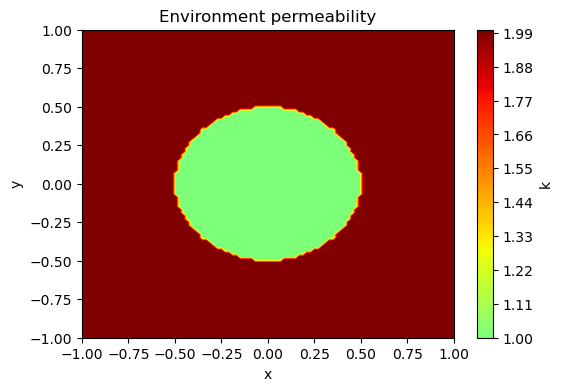

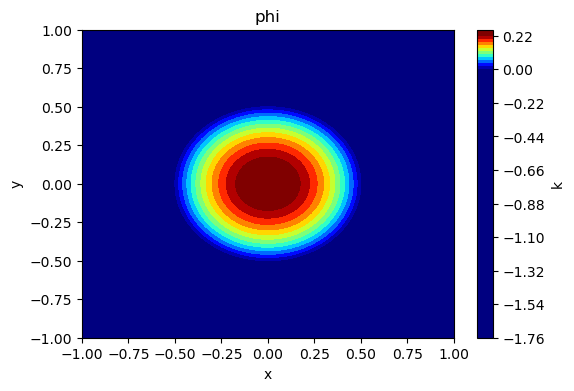

In [21]:
def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    u = model(pde_input)[:, 0]
    u_grad = grad(u, pde_input, torch.ones_like(u), create_graph=True)[0]
    u_grad = u_grad
    u_x, u_y = u_grad[:, 0], u_grad[:, 1]
    
    u_xx = grad(u_x, pde_input, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, pde_input, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    return (u_xx + u_yy)

plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=["Environment permeability"],
    function_names=["k"],
    colour_map='jet',
    vmin=0,
    vmax=2,
    device=device,
    N=100,
    save_img=True,
)

utils.plot_function_on_2d_cube([k], plot_ctx)

plot_ctx.vmax=0.22
plot_ctx.vmin=0
plot_ctx.titles=["phi"]
utils.plot_function_on_2d_cube([phi], plot_ctx)

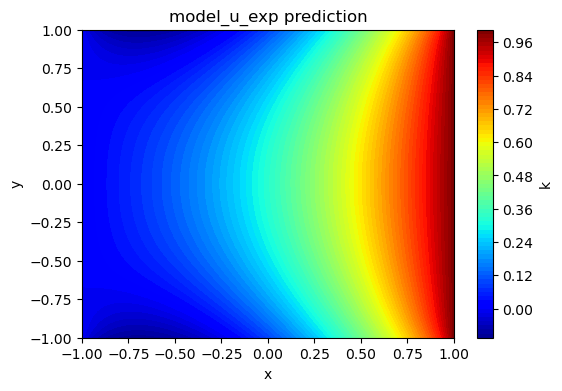

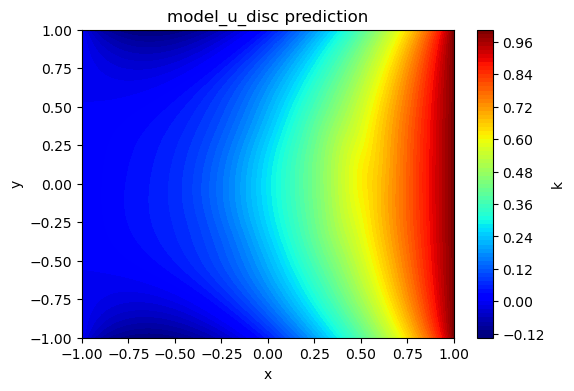

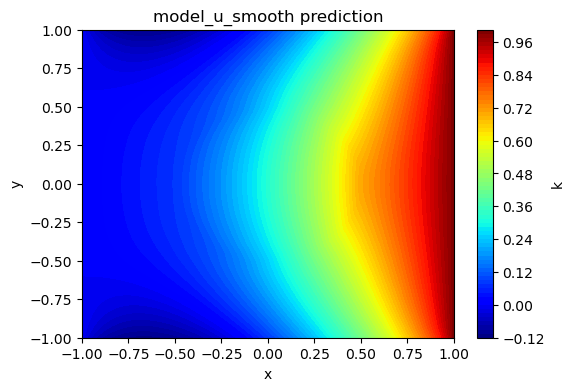

In [22]:
plot_ctx.vmin = -0.12
plot_ctx.vmax = 1

plot_ctx.titles = ['model_u_exp prediction']
plot_ctx.save_path = "./images/model_u_exp_pred.png"
utils.plot_function_on_2d_cube([lambda x: model_combined_exp(x)[:, 0]], plot_ctx)

plot_ctx.titles = ['model_u_disc prediction']
plot_ctx.save_path = "./images/model_u_disc_pred.png"
utils.plot_function_on_2d_cube([lambda x: model_combined_disc(x)[:, 0]], plot_ctx)

plot_ctx.titles = ['model_u_smooth prediction']
plot_ctx.save_path = "./images/model_u_smooth_pred.png"
utils.plot_function_on_2d_cube([lambda x: model_combined_smooth(x)[:, 0]], plot_ctx)

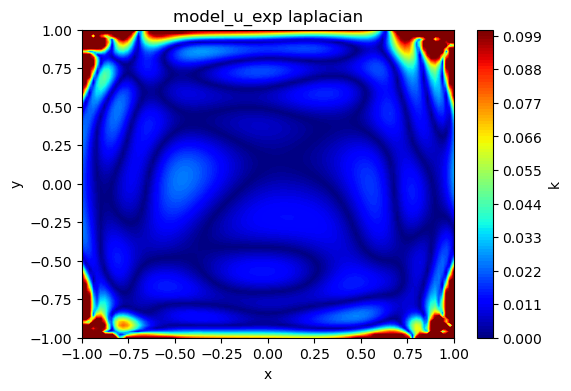

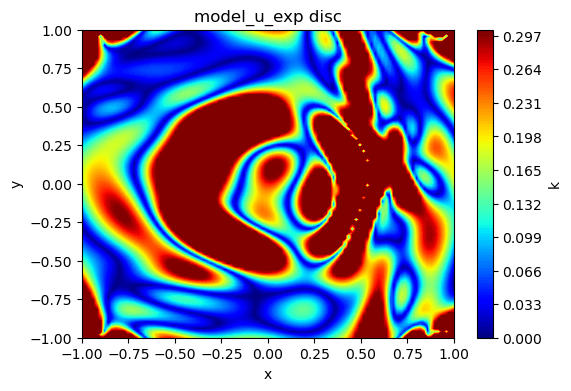

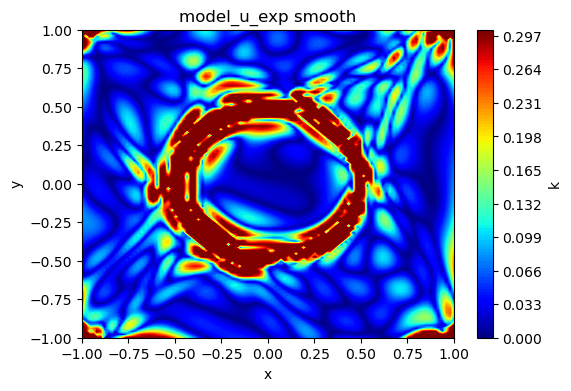

In [23]:
plot_ctx.vmax = 0.1
plot_ctx.vmin = 0.0

plot_ctx.titles = ["model_u_exp laplacian"]
plot_ctx.save_path = "./images/model_u_exp_laplacian.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_exp)), 0.0, 0.1)], plot_ctx)

plot_ctx.vmax = 0.3
plot_ctx.titles = ["model_u_exp disc"]
plot_ctx.save_path = "./images/model_u_disc_laplacian.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_disc)), 0.0, 0.3)], plot_ctx)

plot_ctx.titles = ["model_u_exp smooth"]
plot_ctx.save_path = "./images/model_u_smooth_laplacian.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_smooth)), 0.0, 0.3)], plot_ctx)


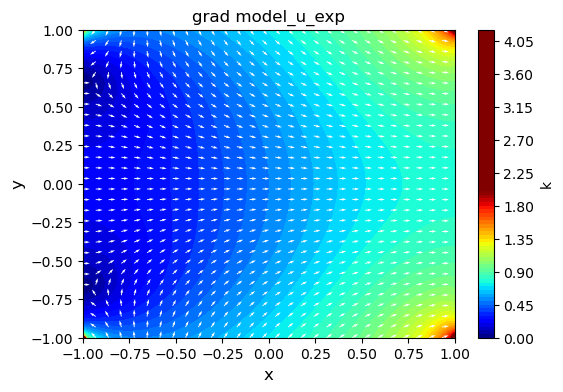

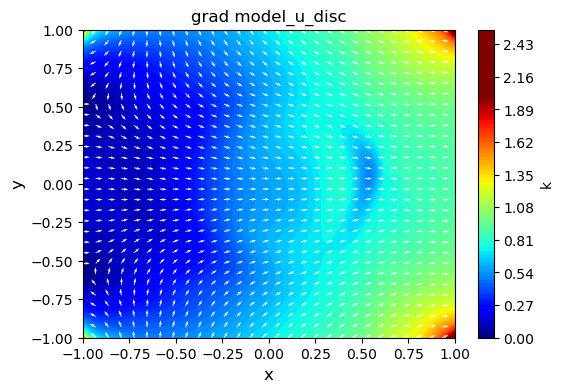

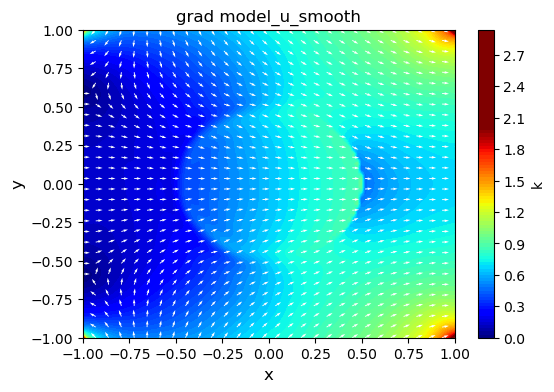

In [24]:

plot_ctx.vmin = 0
plot_ctx.vmax = 2

def heat_flow(x, model):
    x.requires_grad_(True)
    u = model(x)[:, 0]
    
    return grad(u, x, torch.ones_like(u))[0]

plot_ctx.titles = ['grad model_u_exp']
plot_ctx.save_path = "./images/model_u_exp_grad.png"
utils.plot_vector_field_2d([lambda x: heat_flow(x, model_combined_exp)], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['grad model_u_disc']
plot_ctx.save_path = "./images/model_u_disc_grad.png"
utils.plot_vector_field_2d([lambda x: heat_flow(x, model_combined_disc)], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['grad model_u_smooth']
plot_ctx.save_path = "./images/model_u_smooth_grad.png"
utils.plot_vector_field_2d([lambda x: heat_flow(x, model_combined_smooth)], plot_ctx, N=100, n_heigth=30, n_width=30)

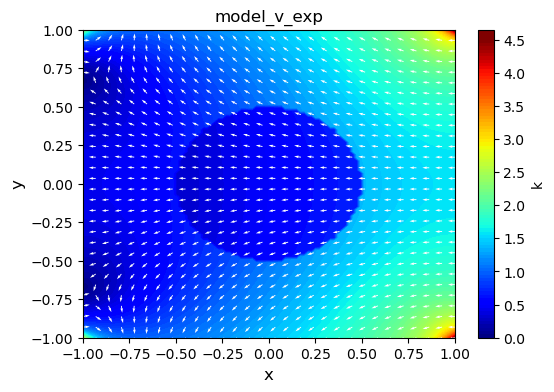

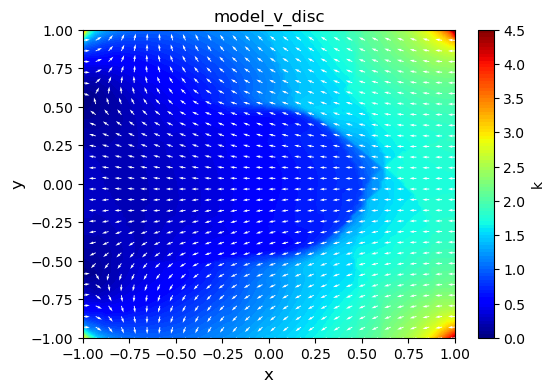

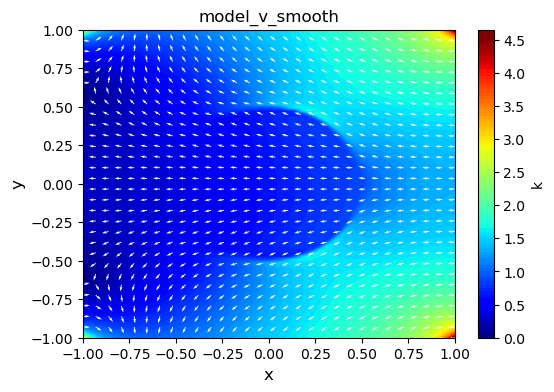

In [25]:

plot_ctx.vmin = 0
plot_ctx.vmax = 4.5

plot_ctx.titles = ['model_v_exp']
plot_ctx.save_path = "./images/model_v_exp.png"
utils.plot_vector_field_2d([lambda x: model_combined_exp(x)[:, 1:] ], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['model_v_disc']
plot_ctx.save_path = "./images/model_v_disc.png"
utils.plot_vector_field_2d([lambda x: model_combined_disc(x)[:, 1:] ], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['model_v_smooth']
plot_ctx.save_path = "./images/model_v_smooth.png"
utils.plot_vector_field_2d([lambda x: model_combined_smooth(x)[:, 1:] ], plot_ctx, N=100, n_heigth=30, n_width=30)

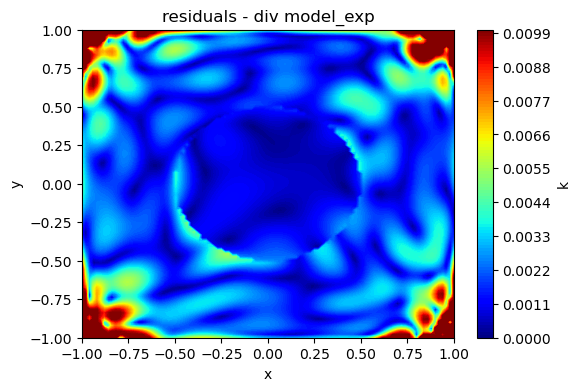

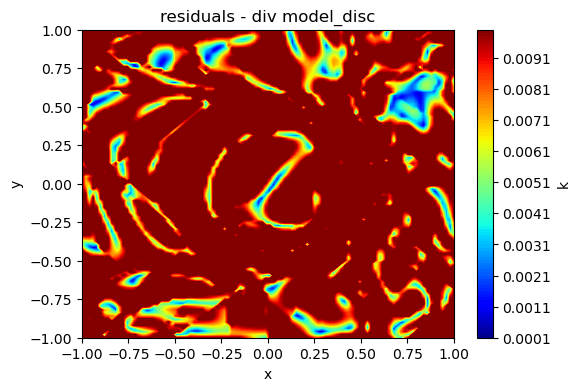

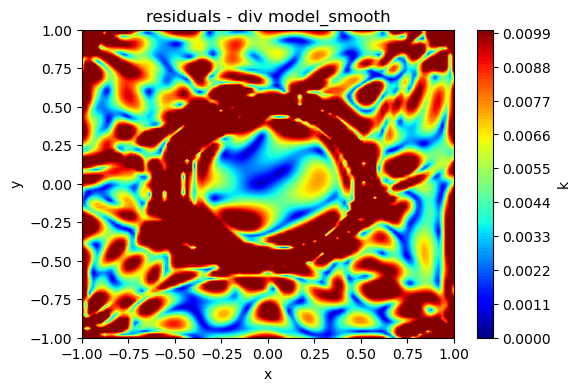

In [26]:
plot_ctx.vmax = 0.01
plot_ctx.vmin = 0.0

def res_div_helper(x, model):
    x.requires_grad_(True)
    out = model(x)
    u = out[:, 0]
    v = out[:, 1:]
    
    res_1, res_2 = res(u, v, x)
        
    return torch.norm(res_1, p=2, dim=1)

plot_ctx.titles = ["residuals - div model_exp"]
plot_ctx.save_path = "./images/model_v_exp_div.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_exp)), 0.0, 0.01)], plot_ctx)

plot_ctx.titles = ["residuals - div model_disc"]
plot_ctx.save_path = "./images/model_v_disc_div.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_disc)), 0.0, 0.01)], plot_ctx)

plot_ctx.titles = ["residuals - div model_smooth"]
plot_ctx.save_path = "./images/model_v_smooth_div.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_smooth)), 0.0, 0.01)], plot_ctx)

In [27]:
from src.calculus import L2_norm

zero_2d = lambda x: torch.zeros(x.shape[0], 2, device=x.device)
zero_1d = lambda x: torch.zeros(x.shape[0], 1, device=x.device)

def make_res1_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        r1, _ = res(u, v, x)
        return r1  # (N, 2)
    return f

def make_res2_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        _, r2 = res(u, v, x)
        return r2.unsqueeze(1)  # (N, 1)
    return f

models_named = {
    "combined_exp":     model_combined_exp,
    "combined_disc":    model_combined_disc,
    "combined_smooth":  model_combined_smooth,
}

print(f"{'Model':<20}  {'L2 ||res1||':>12}  {'L2 ||res2||':>12}")
print("-" * 48)
for name, model in models_named.items():
    l2_r1 = L2_norm(make_res1_fn(model), zero_2d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
    l2_r2 = L2_norm(make_res2_fn(model), zero_1d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
    print(f"{name:<20}  {l2_r1.item():>12.6e}  {l2_r2.item():>12.6e}")


Model                  L2 ||res1||   L2 ||res2||
------------------------------------------------
combined_exp          3.001341e-02  7.903054e-03
combined_disc         1.020337e-01  2.331223e-02
combined_smooth       5.751267e-02  2.689640e-02


/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)
/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)
/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


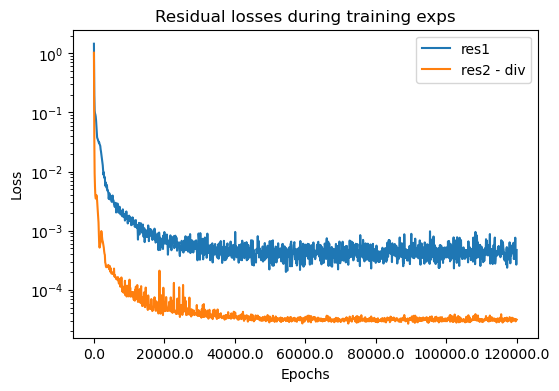

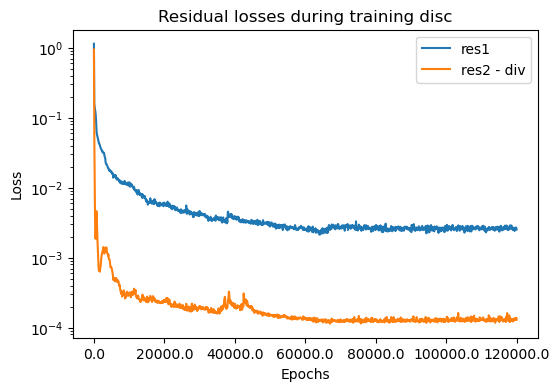

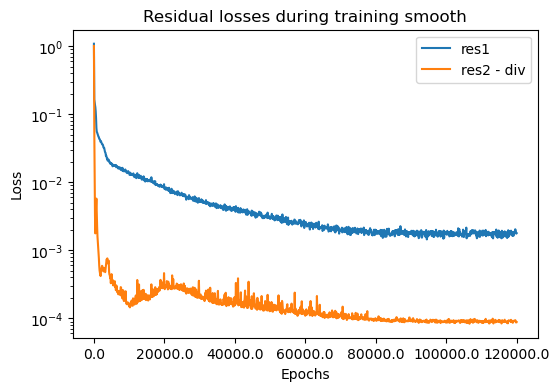

In [28]:
plot_ctx.y_label = 'Loss'
plot_ctx.x_label = 'Epochs'

plot_ctx.titles = ['Residual losses during training exps']
plot_ctx.save_path = "./images/model_exps_losses.png"
utils.plot_loss_values({"res1": loss_comps_exp[0],
                        "res2 - div": loss_comps_exp[1]}, plot_ctx)

plot_ctx.titles = ['Residual losses during training disc']
plot_ctx.save_path = "./images/model_disc_losses.png"
utils.plot_loss_values({"res1": loss_comps_disc[0],
                        "res2 - div": loss_comps_disc[1]}, plot_ctx)

plot_ctx.titles = ['Residual losses during training smooth']
plot_ctx.save_path = "./images/model_smooth_losses.png"
utils.plot_loss_values({"res1": loss_comps_smooth[0],
                        "res2 - div": loss_comps_smooth[1]}, plot_ctx)


In [29]:

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

# ── Load FEM reference solution ──────────────────────────────────────────────
with h5py.File("darcy_solution.h5", "r") as f:
    xy_np    = f["samples/xy"][:]          # (N, 2)
    u_fem    = f["samples/u_interp"][:]    # (N,)
    v_fem_np = f["samples/flux_interp"][:] # (N, 2)  — v = -k ∇u from FEM

xy_fem   = torch.tensor(xy_np,    dtype=torch.float32, device=device)
u_fem_t  = torch.tensor(u_fem,    dtype=torch.float32, device=device)  # (N,)
v_fem_t  = torch.tensor(v_fem_np, dtype=torch.float32, device=device)  # (N, 2)

models = {
    "combined_exp":     model_combined_exp,
    "combined_disc":    model_combined_disc,
    "combined_smooth":  model_combined_smooth,
}

u_true_norm   = torch.linalg.vector_norm(u_fem_t, ord=2)
v_true_norm   = torch.linalg.vector_norm(v_fem_t.reshape(-1), ord=2)
vx_true_norm  = torch.linalg.vector_norm(v_fem_t[:, 0], ord=2)
vy_true_norm  = torch.linalg.vector_norm(v_fem_t[:, 1], ord=2)

# ── Error metrics ────────────────────────────────────────────────────────────
header = (f"{'Model':<20}  {'u L2':>10}  {'u RelL2':>10}  {'u RMSE':>10}"
          f"  {'v L2':>10}  {'v RelL2':>10}  {'v RMSE':>10}"
          f"  {'vx L2':>10}  {'vx RelL2':>10}  {'vx RMSE':>10}"
          f"  {'vy L2':>10}  {'vy RelL2':>10}  {'vy RMSE':>10}")
print(header)
print("-" * len(header))

u_err_maps  = {}
v_err_maps  = {}
vx_err_maps = {}
vy_err_maps = {}

for name, model in models.items():
    model.eval()
    with torch.no_grad():
        out    = model(xy_fem)
        u_pred = out[:, 0]          # (N,)
        v_pred = out[:, 1:]         # (N, 2)

        u_err     = (u_pred - u_fem_t).abs()
        u_l2      = torch.linalg.vector_norm(u_err, ord=2)
        u_rel_l2  = u_l2 / (u_true_norm + 1e-12)
        u_rmse    = torch.sqrt(torch.mean((u_pred - u_fem_t)**2))

        v_err_mag = torch.norm(v_pred - v_fem_t, dim=1, p=2)   # (N,)
        v_l2      = torch.linalg.vector_norm(v_err_mag, ord=2)
        v_rel_l2  = v_l2 / (v_true_norm + 1e-12)
        v_rmse    = torch.sqrt(torch.mean((v_pred - v_fem_t)**2))

        vx_err    = (v_pred[:, 0] - v_fem_t[:, 0]).abs()
        vx_l2     = torch.linalg.vector_norm(vx_err, ord=2)
        vx_rel_l2 = vx_l2 / (vx_true_norm + 1e-12)
        vx_rmse   = torch.sqrt(torch.mean((v_pred[:, 0] - v_fem_t[:, 0])**2))

        vy_err    = (v_pred[:, 1] - v_fem_t[:, 1]).abs()
        vy_l2     = torch.linalg.vector_norm(vy_err, ord=2)
        vy_rel_l2 = vy_l2 / (vy_true_norm + 1e-12)
        vy_rmse   = torch.sqrt(torch.mean((v_pred[:, 1] - v_fem_t[:, 1])**2))

    u_err_maps[name]  = u_err.cpu().numpy()
    v_err_maps[name]  = v_err_mag.cpu().numpy()
    vx_err_maps[name] = vx_err.cpu().numpy()
    vy_err_maps[name] = vy_err.cpu().numpy()

    print(f"{name:<20}  {u_l2.item():>10.4e}  {u_rel_l2.item():>10.4e}  {u_rmse.item():>10.4e}"
          f"  {v_l2.item():>10.4e}  {v_rel_l2.item():>10.4e}  {v_rmse.item():>10.4e}"
          f"  {vx_l2.item():>10.4e}  {vx_rel_l2.item():>10.4e}  {vx_rmse.item():>10.4e}"
          f"  {vy_l2.item():>10.4e}  {vy_rel_l2.item():>10.4e}  {vy_rmse.item():>10.4e}")


Model                       u L2     u RelL2      u RMSE        v L2     v RelL2      v RMSE       vx L2    vx RelL2     vx RMSE       vy L2    vy RelL2     vy RMSE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
combined_exp          2.3551e+00  5.1069e-02  2.3551e-02         nan         nan         nan         nan         nan         nan         nan         nan         nan
combined_disc         3.7447e+00  8.1203e-02  3.7447e-02         nan         nan         nan         nan         nan         nan         nan         nan         nan
combined_smooth       4.5987e-02  9.9722e-04  4.5987e-04         nan         nan         nan         nan         nan         nan         nan         nan         nan


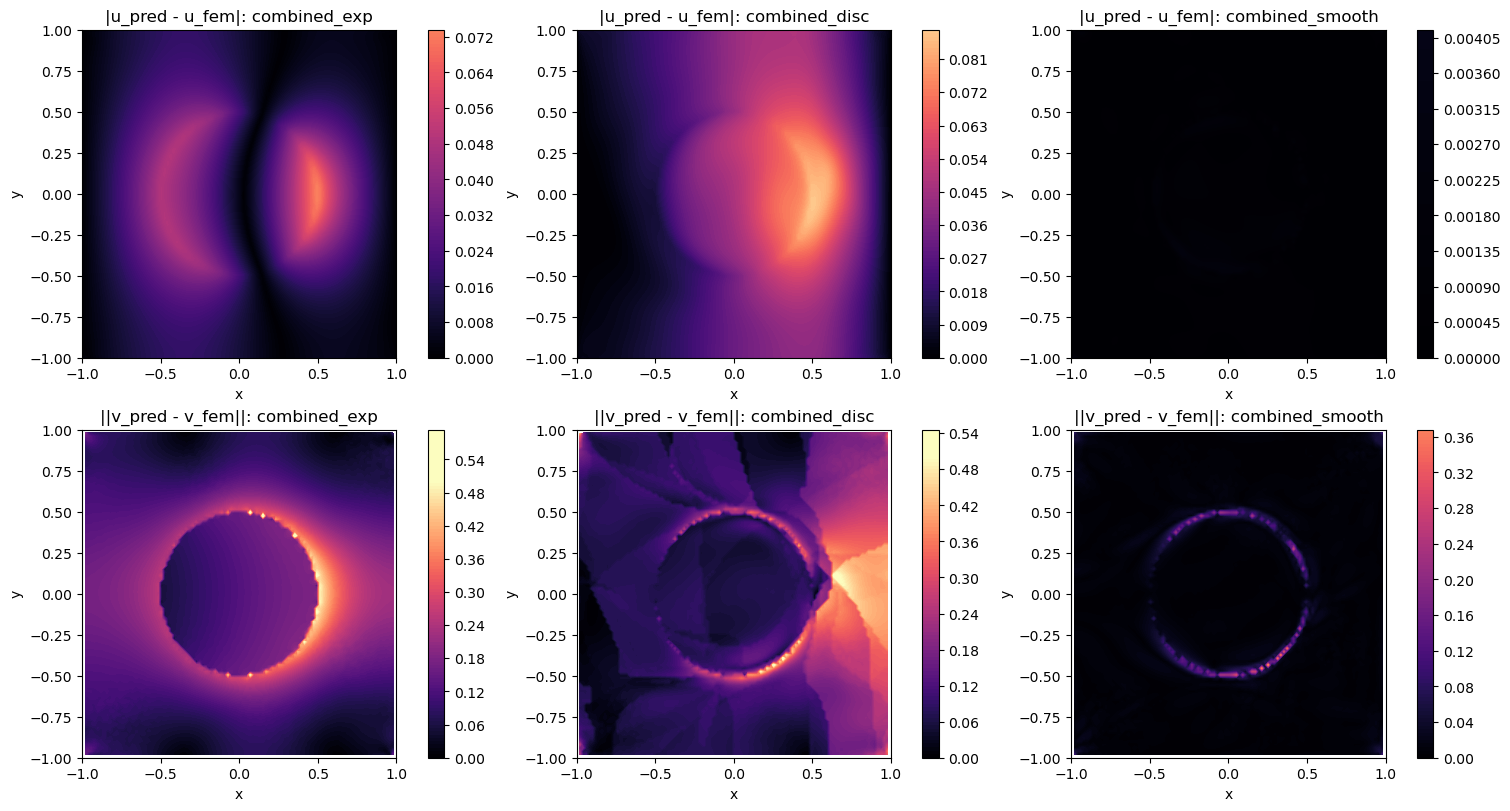

In [30]:

# ── Plot error maps: u and ||v|| ─────────────────────────────────────────────
xs = np.unique(xy_np[:, 0])
ys = np.unique(xy_np[:, 1])
nx, ny = len(xs), len(ys)
X = xy_np[:, 0].reshape(nx, ny)
Y = xy_np[:, 1].reshape(nx, ny)

n_models = len(models)

fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 8), constrained_layout=True)

for col, name in enumerate(models.keys()):
    # pressure error
    ax = axes[0, col]
    E = u_err_maps[name].reshape(nx, ny)
    c = ax.contourf(X, Y, E, levels=100, cmap="magma", vmin=0.0, vmax=0.1)
    ax.set_title(f"|u_pred - u_fem|: {name}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    fig.colorbar(c, ax=ax)

    # flux magnitude error
    ax2 = axes[1, col]
    V = v_err_maps[name].reshape(nx, ny)
    c2 = ax2.contourf(X, Y, V, levels=100, cmap="magma", vmin=0.0, vmax=0.5)
    ax2.set_title(f"||v_pred - v_fem||: {name}")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    fig.colorbar(c2, ax=ax2)

plt.savefig("./images/model_errors_uv.png")
plt.show()


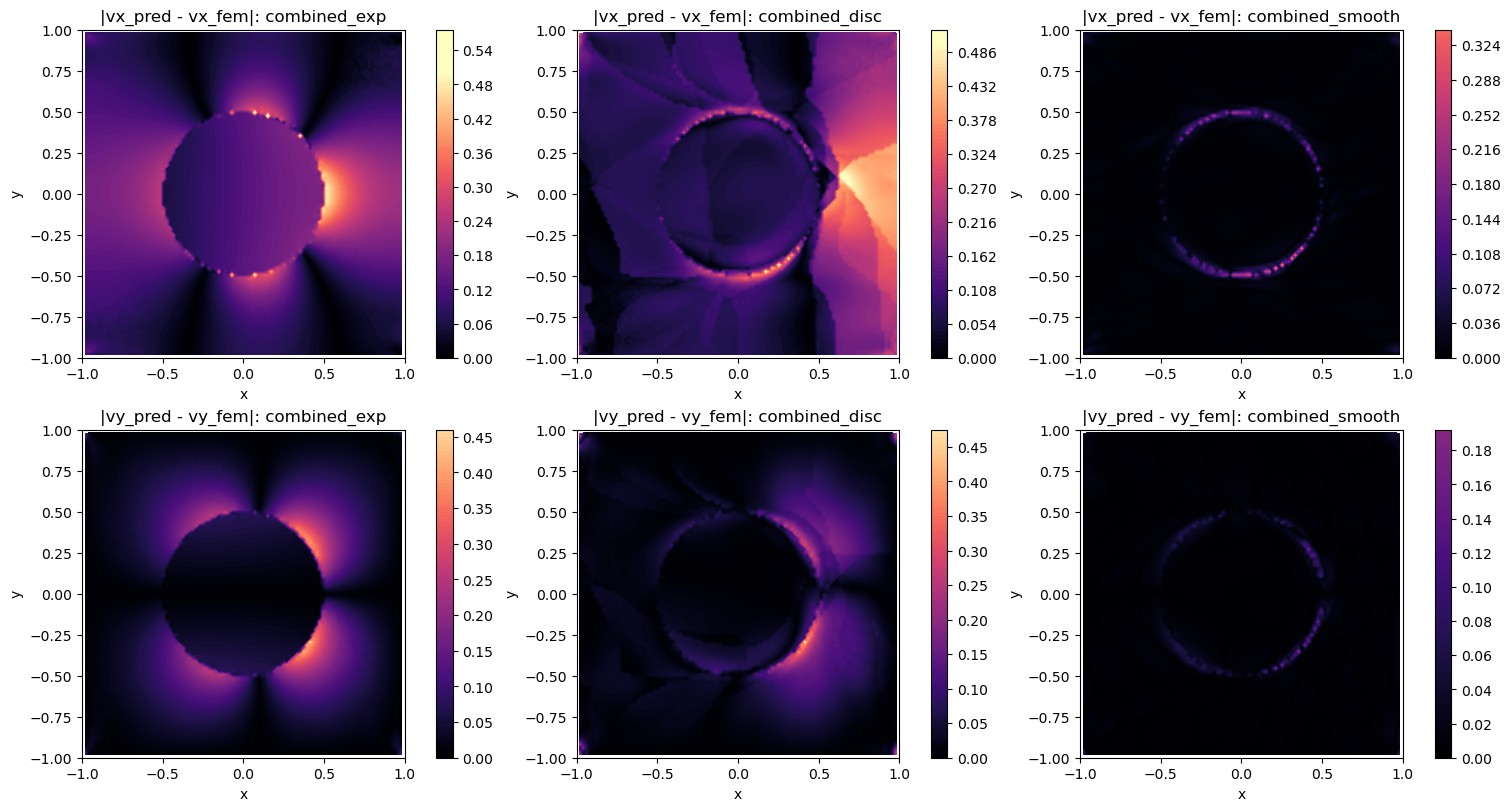

In [31]:

# ── Plot error maps: vx and vy components ────────────────────────────────────
fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 8), constrained_layout=True)

for col, name in enumerate(models.keys()):
    # vx component error
    ax = axes[0, col]
    Vx = vx_err_maps[name].reshape(nx, ny)
    c = ax.contourf(X, Y, Vx, levels=100, cmap="magma", vmin=0.0, vmax=0.5)
    ax.set_title(f"|vx_pred - vx_fem|: {name}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    fig.colorbar(c, ax=ax)

    # vy component error
    ax2 = axes[1, col]
    Vy = vy_err_maps[name].reshape(nx, ny)
    c2 = ax2.contourf(X, Y, Vy, levels=100, cmap="magma", vmin=0.0, vmax=0.5)
    ax2.set_title(f"|vy_pred - vy_fem|: {name}")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    fig.colorbar(c2, ax=ax2)

plt.savefig("./images/model_errors_vcomps.png")
plt.show()


In [32]:
def max_param_drift(model: torch.nn.Module, init_model: torch.nn.Module) -> float:
    learned = model.state_dict()
    initial = init_model.state_dict()
    return max(
        (learned[k].float() - initial[k].float()).abs().max().item()
        for k in learned
    )

pairs = {
    "combined_exp":     (model_combined_exp,      model_init_exp),
    "combined_disc":    (model_combined_disc,     model_init_disc),
    "combined_smooth":  (model_combined_smooth,   model_init_smooth),
}

print(f"{'Model':<20}  {'Max |Δ param|':>14}  {'Mean |Δ param|':>15}")
print("-" * 54)
for name, (trained, init) in pairs.items():
    learned = trained.state_dict()
    initial = init.state_dict()
    deltas = [(learned[k].float() - initial[k].float()).abs() for k in learned]
    max_drift  = max(d.max().item() for d in deltas)
    mean_drift = sum(d.mean().item() for d in deltas) / len(deltas)
    print(f"{name:<20}  {max_drift:>14.6e}  {mean_drift:>15.6e}")


Model                  Max |Δ param|   Mean |Δ param|
------------------------------------------------------
combined_exp            6.211763e+00     9.248467e-02
combined_disc           5.751117e+00     1.048327e-01
combined_smooth         5.750186e+00     1.642654e-01
